# Baseline vs. photoshop_spline_model comparison

Side-by-side comparison of `ppspline.make_spline_model` with hand-picked defaults
(`sfac=1.0, k=3`, as used in `runPP.py`) against `photoshop_spline_model`'s
cross-validation-based auto-tuned hyperparameters, on the same aligned archive.

Two independent `DataPortrait` instances are used throughout (`dp_baseline` and
`dp_photoshop`) since fitting a model mutates the instance's state -- this lets
both models coexist for comparison rather than one overwriting the other.

**Expect the photoshop cell to take a few minutes** (cross-validated search over
wavelet/k/sfac/max_nbreak); reduce `nrepeat` below for a quicker sanity check at
the cost of noisier hyperparameter selection.

In [1]:
import sys, os, time

# Make sure this repo and the PSRCHIVE Python bindings are importable regardless
# of how this notebook's kernel was launched.
sys.path.insert(0, '/home/willem/Pulsar/PulsePortraiture')
psrchive_path = '/home/willem/Pulsar/lib/python3.9/site-packages'
if psrchive_path not in sys.path:
    sys.path.insert(0, psrchive_path)

%matplotlib inline
import numpy as np
import pandas as pd
import ppspline as pps

## Load two independent copies of the aligned archive

In [2]:
archive = 'J0000+0000_ppaligned.ar'
if not os.path.exists(archive):
    raise FileNotFoundError(
        "%s not found -- run runPP.py in this directory first to produce it."
        % archive)

dp_baseline = pps.DataPortrait(archive, quiet=True)
dp_baseline.normalize_portrait('prof')

dp_photoshop = pps.DataPortrait(archive, quiet=True)
dp_photoshop.normalize_portrait('prof')

## Baseline: `make_spline_model` with hand-picked defaults

In [3]:
t0 = time.time()
dp_baseline.make_spline_model(max_ncomp=None, smooth=True, snr_cutoff=150,
        rchi2_tol=0.1, k=3, sfac=1.0, max_nbreak=None, quiet=False)
print('baseline fit took %.1f s' % (time.time() - t0))

Performing principal component analysis on data with 1024 dimensions and 16 measurements...
B-spline interpolation model J0000+0000_ppaligned.ar.spl uses 2 basis profile components and 3 breakpoints (5 B-splines with k=3).
baseline fit took 24.0 s


/home/willem/.local/lib/python3.9/site-packages/scipy/interpolate/_fitpack_py.py:155: RuntimeWarning: The spline has a residual sum of squares fp such that abs(fp-s)/s<=0.001	k=3 n=9 m=16 fp=316.364808 s=316.383338
  res = _impl.splprep(x, w, u, ub, ue, k, task, s, t, full_output, nest, per,


/home/willem/.local/lib/python3.9/site-packages/scipy/interpolate/_fitpack_py.py:155: RuntimeWarning: The spline has a residual sum of squares fp such that abs(fp-s)/s<=0.001	k=3 n=9 m=16 fp=316.364808 s=316.383338
  res = _impl.splprep(x, w, u, ub, ue, k, task, s, t, full_output, nest, per,


## Photoshop: cross-validation-based auto-tuned hyperparameters

In [4]:
# Reduce nrepeat (e.g. to 3-5) for a much faster, noisier sanity check.
nrepeat = 10

t0 = time.time()
best = dp_photoshop.photoshop_spline_model(max_ncomp=None, snr_cutoff=150,
        rchi2_tol=0.1,
        wavelets=('db4', 'db8', 'db12', 'db20', 'sym8', 'sym12', 'coif4'),
        ks=(1, 3, 5), max_nbreak_candidates=(None,),
        test_frac=0.2, nrepeat=nrepeat, seed=42, apply=True, quiet=False,
        decouple_wavelet=True)
print('photoshop fit took %.1f s' % (time.time() - t0))
print('chosen (wavelet, k, sfac, max_nbreak):', best)

select_wavelet: wavelet 'db4' residual zero-crossing fraction = 0.4878 (0.5 = ideal white-noise residual).
select_wavelet: wavelet 'db8' residual zero-crossing fraction = 0.5249 (0.5 = ideal white-noise residual).
select_wavelet: wavelet 'db12' residual zero-crossing fraction = 0.5249 (0.5 = ideal white-noise residual).
select_wavelet: wavelet 'db20' residual zero-crossing fraction = 0.5269 (0.5 = ideal white-noise residual).
select_wavelet: wavelet 'sym8' residual zero-crossing fraction = 0.5327 (0.5 = ideal white-noise residual).
select_wavelet: wavelet 'sym12' residual zero-crossing fraction = 0.5269 (0.5 = ideal white-noise residual).
select_wavelet: wavelet 'coif4' residual zero-crossing fraction = 0.5327 (0.5 = ideal white-noise residual).
select_wavelet: selected wavelet 'db4' (residual zero-crossing fraction = 0.4878).
photoshop_spline_model: fitting 10 train/test splits for wavelet 'db4'...
photoshop_spline_model: selected wavelet=db4, k=5, sfac=0.3162, max_nbreak=None (CV red

/home/willem/.local/lib/python3.9/site-packages/scipy/interpolate/_fitpack_py.py:155: RuntimeWarning: The spline is weighted least-squares polynomial of degree k.
fp gives the upper bound fp0 for the smoothing factor s	k=5 n=12 m=16 fp=55.237177 s=100.049196
  res = _impl.splprep(x, w, u, ub, ue, k, task, s, t, full_output, nest, per,


select_wavelet: wavelet 'db12' residual zero-crossing fraction = 0.5249 (0.5 = ideal white-noise residual).


select_wavelet: wavelet 'db20' residual zero-crossing fraction = 0.5269 (0.5 = ideal white-noise residual).


select_wavelet: wavelet 'sym8' residual zero-crossing fraction = 0.5327 (0.5 = ideal white-noise residual).


select_wavelet: wavelet 'sym12' residual zero-crossing fraction = 0.5269 (0.5 = ideal white-noise residual).


select_wavelet: wavelet 'coif4' residual zero-crossing fraction = 0.5327 (0.5 = ideal white-noise residual).
select_wavelet: selected wavelet 'db4' (residual zero-crossing fraction = 0.4878).
photoshop_spline_model: fitting 10 train/test splits for wavelet 'db4'...


photoshop_spline_model: selected wavelet=db4, k=5, sfac=0.3162, max_nbreak=None (CV reduced chi2 = 1.0105 +/- 0.0086; global minimum was 1.0105 +/- 0.0086).
Performing principal component analysis on data with 1024 dimensions and 16 measurements...


B-spline interpolation model J0000+0000_ppaligned.ar.spl uses 2 basis profile components and 2 breakpoints (6 B-splines with k=5).
photoshop fit took 186.4 s
chosen (wavelet, k, sfac, max_nbreak): ('db4', 5, 0.31622776601683794, None)


/home/willem/.local/lib/python3.9/site-packages/scipy/interpolate/_fitpack_py.py:155: RuntimeWarning: The spline is weighted least-squares polynomial of degree k.
fp gives the upper bound fp0 for the smoothing factor s	k=5 n=12 m=16 fp=55.237177 s=100.049196
  res = _impl.splprep(x, w, u, ub, ue, k, task, s, t, full_output, nest, per,


## Hyperparameters and model complexity, side by side

In [5]:
def model_summary(dp, label):
    nbreak = len(np.unique(dp.tck[0]))
    nspline = len(dp.tck[0]) - dp.tck[2] - 1
    return dict(model=label, wavelet=getattr(dp, 'model_name', None) and None,
                k=dp.tck[2], ncomp=dp.ncomp, breakpoints=nbreak,
                n_bsplines=nspline)

summary = pd.DataFrame([
    dict(model='baseline', wavelet='db8 (fixed)', k=dp_baseline.tck[2],
         sfac=1.0, max_nbreak=None, ncomp=dp_baseline.ncomp,
         breakpoints=len(np.unique(dp_baseline.tck[0])),
         n_bsplines=len(dp_baseline.tck[0]) - dp_baseline.tck[2] - 1),
    dict(model='photoshop', wavelet=best[0], k=best[1], sfac=best[2],
         max_nbreak=best[3], ncomp=dp_photoshop.ncomp,
         breakpoints=len(np.unique(dp_photoshop.tck[0])),
         n_bsplines=len(dp_photoshop.tck[0]) - dp_photoshop.tck[2] - 1),
])
summary

,model,wavelet,k,sfac,max_nbreak,ncomp,breakpoints,n_bsplines
0,baseline,db8 (fixed),3,1.000000,None,2,3,5
1,photoshop,db4,5,0.316228,None,2,2,6


## Eigenprofiles: baseline vs. photoshop

Mean profile and significant eigenprofiles (raw vs. wavelet-smoothed), with S/N
estimates -- compare how aggressively each model's chosen wavelet/level smooths
the same underlying components.

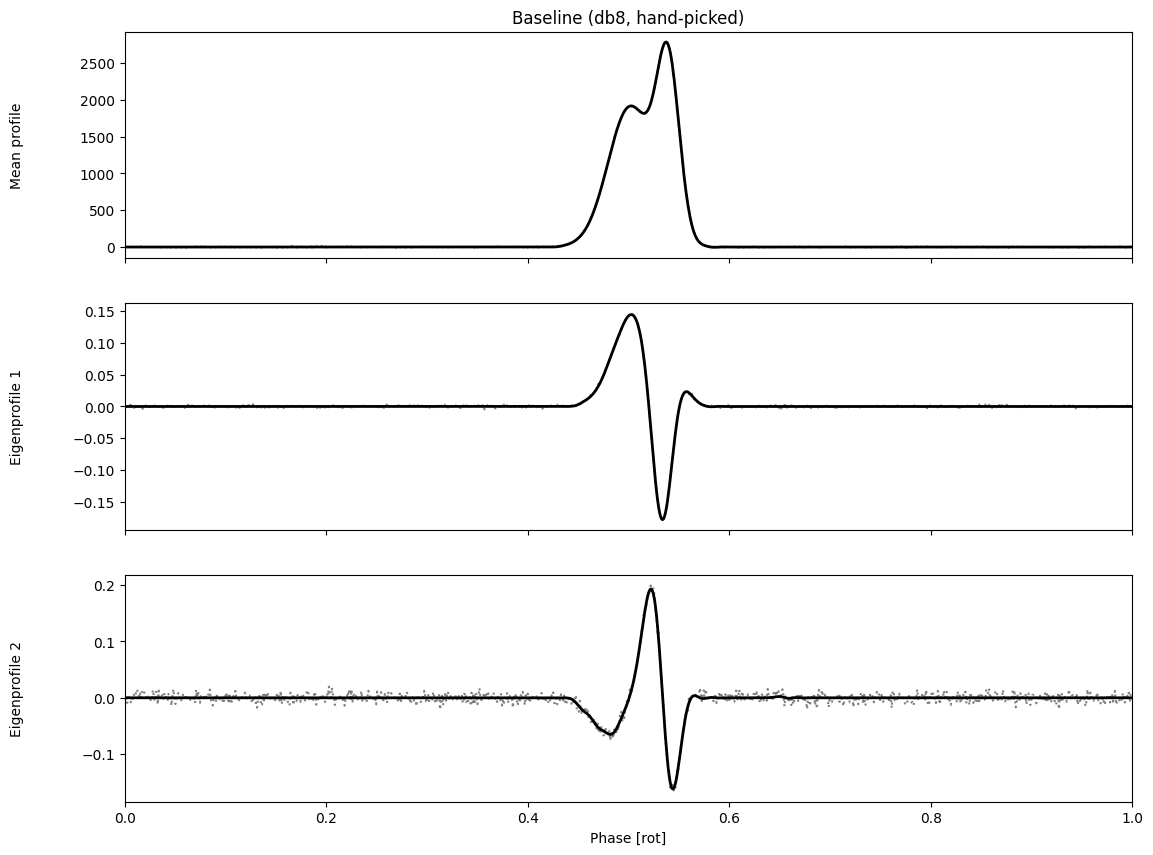

In [6]:
dp_baseline.show_eigenprofiles(title='Baseline (db8, hand-picked)')

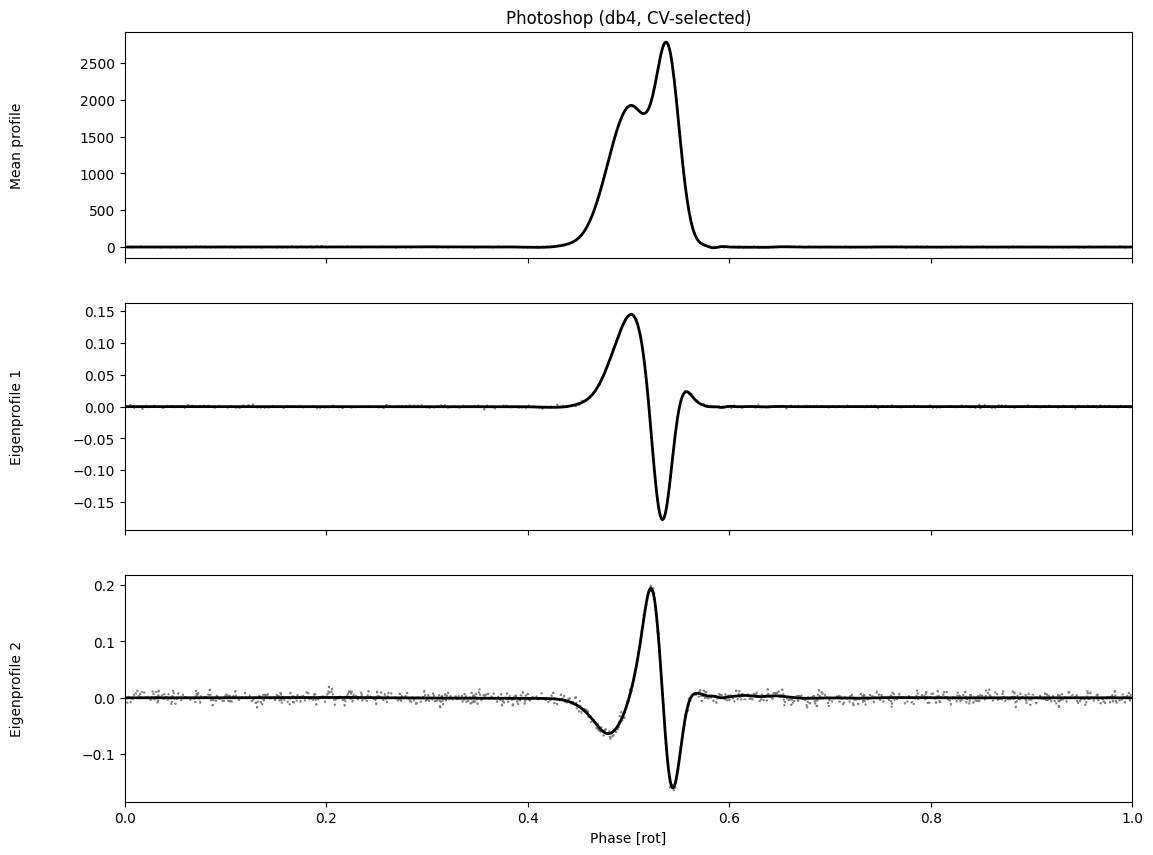

In [7]:
dp_photoshop.show_eigenprofiles(title='Photoshop (%s, CV-selected)' % best[0])

## Spline curve projections: baseline vs. photoshop

The B-spline curves fit to each eigenprofile's projection vs. frequency -- the
most direct view of whether `sfac`/`k`/`max_nbreak` are over- or under-smoothing
the frequency evolution.

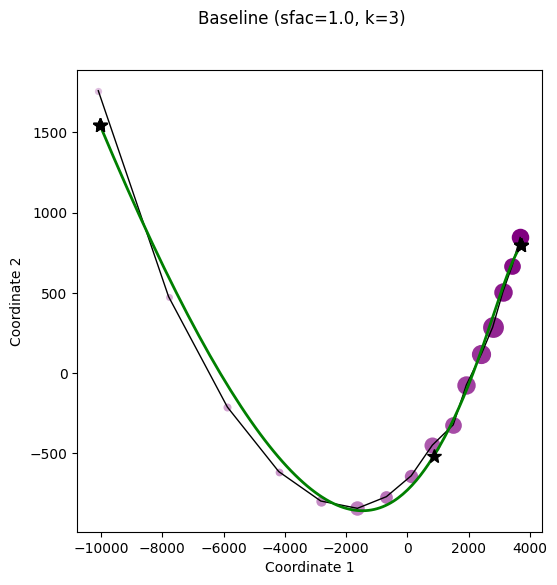

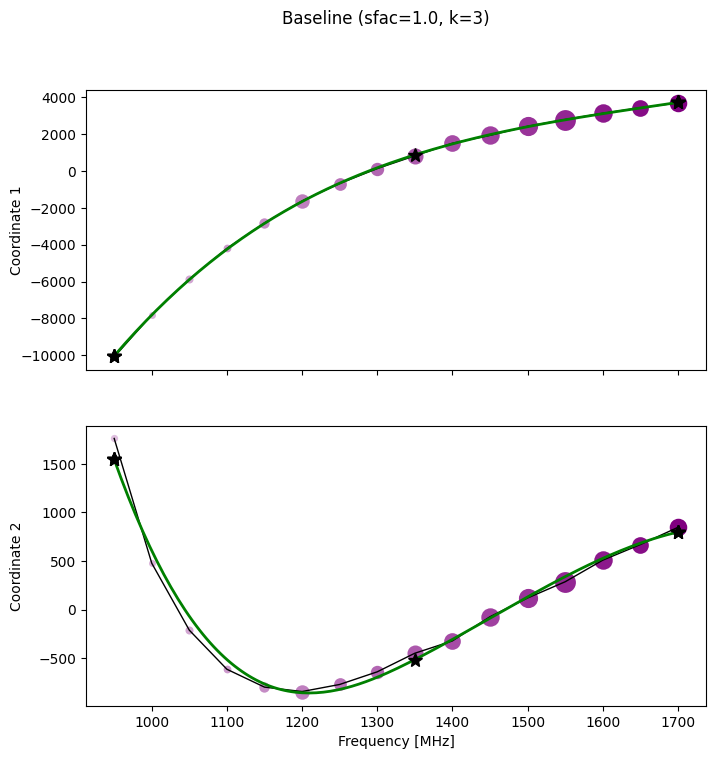

In [8]:
dp_baseline.show_spline_curve_projections(title='Baseline (sfac=1.0, k=3)')

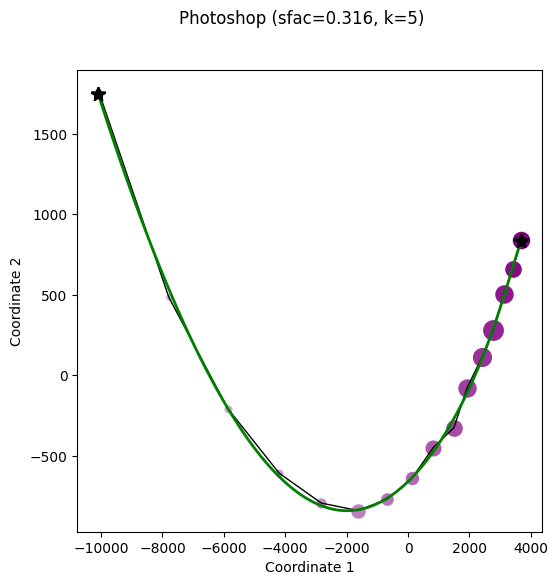

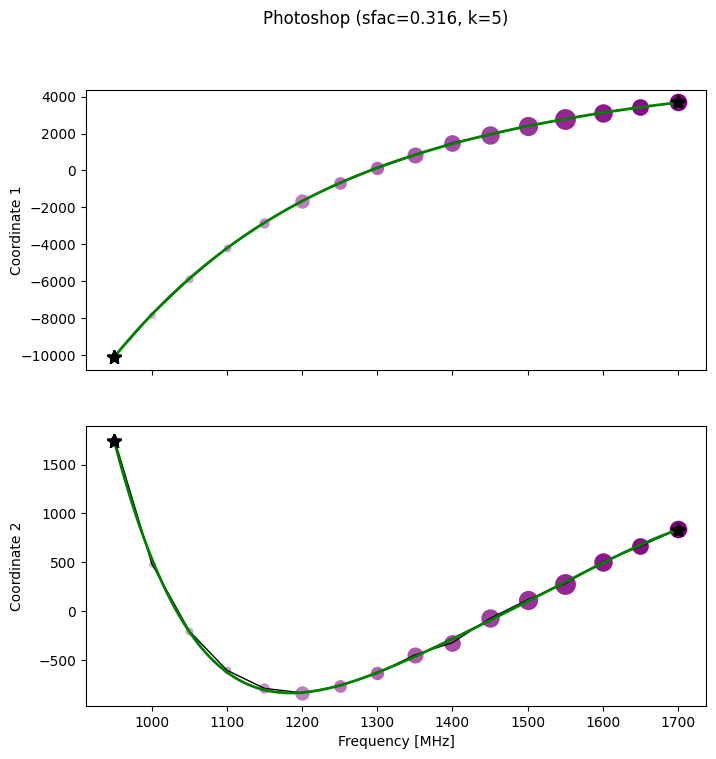

In [9]:
dp_photoshop.show_spline_curve_projections(
        title='Photoshop (sfac=%.3g, k=%d)' % (best[2], best[1]))

## Model fit / residuals: baseline vs. photoshop

Data, model, and residual portraits, plus the distribution of per-channel
reduced chi-squared -- should cluster near 1.0 for a well-fit model.

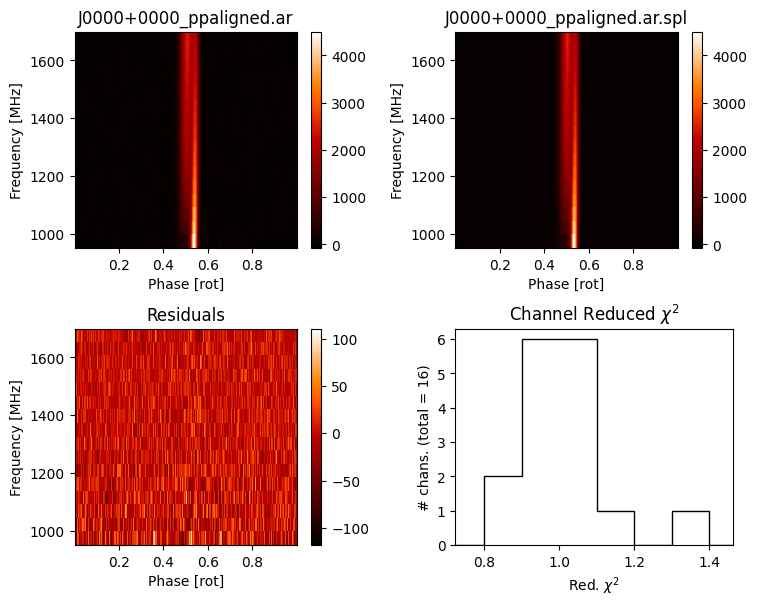

In [10]:
dp_baseline.show_model_fit()

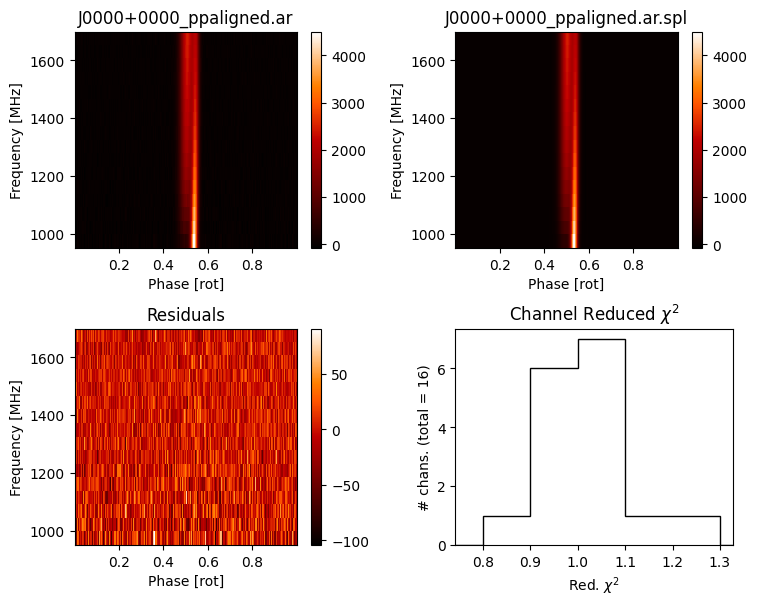

In [11]:
dp_photoshop.show_model_fit()

## `photoshop_results`: the full cross-validation grid

Every `(wavelet, k, max_nbreak, sfac)` combination tried, with its
cross-validated out-of-sample reduced chi-squared (`score`) and standard error
(`se`) across the `nrepeat` train/test splits. Lower `score` is better (closer to
1.0 is ideal -- below 1.0 can indicate overfitting to the held-out noise, not
genuinely better generalization). The selected row is highlighted.

In [12]:
results_df = pd.DataFrame([dict(wavelet=r.wavelet, k=r.k,
        max_nbreak=r.max_nbreak, sfac=r.sfac, score=r.score, se=r.se)
        for r in dp_photoshop.photoshop_results])
results_df = results_df.sort_values('score').reset_index(drop=True)

def _highlight_selected(row):
    is_selected = (row.wavelet == best[0] and row.k == best[1]
            and row.max_nbreak == best[3])
    return ['background-color: #d7f5d7' if is_selected else '' for _ in row]

results_df.style.apply(_highlight_selected, axis=1).format(
        {'sfac': '{:.4g}', 'score': '{:.4f}', 'se': '{:.4f}'})

,wavelet,k,max_nbreak,sfac,score,se
0,db4,5,None,0.3162,1.0105,0.0086
1,db4,3,None,0.2545,1.0110,0.0082
2,db4,1,None,8.029e-07,1.0655,0.0185


## `select_wavelet` scores: residual whiteness per candidate wavelet

For reference, the mean-profile-only wavelet-selection step from
`photoshop_spline_model` (see `select_wavelet(...)`): each candidate's residual
zero-crossing fraction (0.5 = ideal white-noise residual) and the pseudo-S/N
`smart_smooth` achieved (kept for inspection only -- not used to rank wavelets,
since it scales with filter length rather than denoising quality).

In [13]:
wavelet_scores_df = pd.DataFrame([
    dict(wavelet=w, residual_crossing_frac=info.residual_crossing_frac,
         snr=info.snr)
    for w, info in dp_photoshop.photoshop_wavelet_scores.items()
]).sort_values(
    by='residual_crossing_frac',
    key=lambda s: (s - 0.5).abs(),
).reset_index(drop=True)
wavelet_scores_df

,wavelet,residual_crossing_frac,snr
0,db4,0.487781,1.307560e+12
1,db8,0.524927,3.307416e+14
2,db12,0.524927,1.296038e+16
3,db20,0.526882,1.592342e+19
4,sym12,0.526882,1.371667e+16
5,sym8,0.532747,3.388386e+14
6,coif4,0.532747,3.693393e+14
